# Random Walk Strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
SPLIT_DATE = "2021-01-01"
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK = 3
n_train_tickers= 1000

##### Data Prep

In [3]:
NEEDED_COLS = [
    TICKER_COL1, TICKER_COL2, DATE_COL,
    'dlyclose', 'dlycap', 'dlyprc', 'dlyvol', 'dlyret', 'dlyprcvol', 'dlyask', 'dlybid'
]
data = pd.read_parquet('./data/dsf/', engine='pyarrow', columns=NEEDED_COLS)
data[DATE_COL] = pd.to_datetime(data[DATE_COL])
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1_000_000
data.head()

,permno,ticker,dlycaldt,dlyclose,dlycap,dlyprc,dlyvol,dlyret,dlyprcvol,dlyask,dlybid,tot_shares,true_prc
0,10001,EGAS,2010-01-04,10.25,44700.25,10.25,18500.0,-0.004854,189625.0,10.26,10.21,4361.0,0.0447
1,10002,BTFG,2010-01-04,3.1,54665.4,3.1,27845.0,0.080139,86319.5,3.25,3.01,17634.0,0.054665
2,10025,AEPI,2010-01-04,39.56,271065.12,39.56,33721.0,0.033438,1334002.8,39.62,39.54,6852.0,0.271065
3,10026,JJSF,2010-01-04,40.2,738634.8,40.2,47859.0,0.006006,1923931.8,40.2,40.13,18374.0,0.738635
4,10028,DGSE,2010-01-04,1.4001,13768.58,1.4001,3900.0,-0.007021,5460.4,1.42,1.4,9834.0,0.013769


##### Trading Strategy

In [4]:
def trade_strat_single(df, curr_b=1000, exit_prop=1.0):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():
        num = row[NUM_COL]
        
        ### This is the random walk
        buy = np.random.normal() > 0

        ### Buy signal
        if buy:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [5]:
def trade_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = trade_strat_single(df, curr_b=curr_b, exit_prop=exit_prop)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    return ret_df

In [6]:
filename = f"./data/random_walk_test_returns_072426_01.csv"
test_data = data[data[DATE_COL] >= SPLIT_DATE].reset_index(drop=True)
pred_tickers = test_data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
ret_df = trade_strat(test_data, pred_tickers.values)
ret_df.to_csv(filename, index=False)

# ret_df = pd.read_csv(filename)
# ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

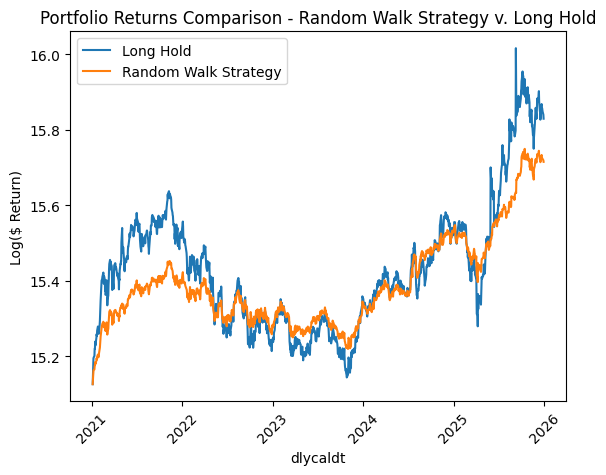

In [7]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Random Walk Strategy")

plt.title("Portfolio Returns Comparison - Random Walk Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

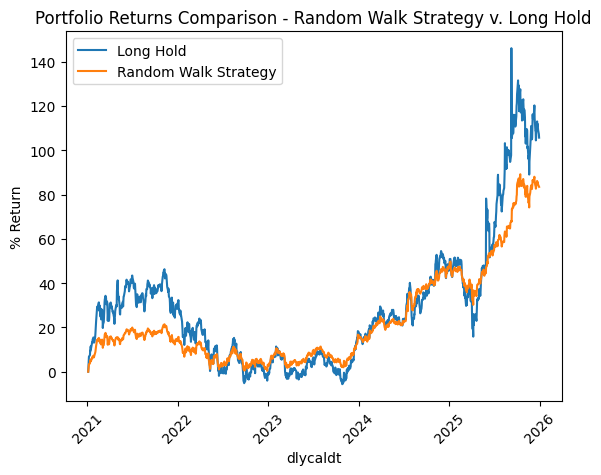

In [8]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Random Walk Strategy")

plt.title("Portfolio Returns Comparison - Random Walk Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()